# PRJ_06_01 LangGraph Legal PDF QA - DB 생성

법률 PDF를 조항 단위로 파싱하고 Chroma 벡터 DB를 생성하는 수업용 노트북입니다.


## 1. 환경 설정과 라이브러리
- 작업: Legal PDF -> Chroma vector DB builder.
- embedding model : ollama 'bge-m3' 모델



In [1]:
from __future__ import annotations
# 타입 힌트를 즉시 해석하지 않고 나중에 평가하도록 하여,
# 아직 정의되지 않은 클래스나 복잡한 타입 참조를 더 쉽게 작성하게 해주는 기능

import re
import shutil

from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

from dotenv import load_dotenv

from langchain_chroma import Chroma
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.documents import Document
from langchain_ollama import OllamaEmbeddings

import warnings
warnings.filterwarnings("ignore")


C:\Users\Admin\AppData\Local\Temp\ipykernel_21612\1557482953.py:15: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


## 2. 기본 환경 설정


2-1. env 환경변수

In [2]:
load_dotenv()

True

2-2. 디렉토리 정보

In [3]:
# Jupyter Notebook에서는 __file__ 대신 현재 작업 폴더를 기준으로 사용
BASE_DIR = Path.cwd()

# 원본 PDF 저장 폴더
DATA_DIR = BASE_DIR / "data"

# Chroma Vector DB 저장 폴더
CHROMA_DIR = BASE_DIR / "chroma_db"

print("BASE_DIR   :", BASE_DIR)
print("DATA_DIR   :", DATA_DIR)
print("CHROMA_DIR :", CHROMA_DIR)


BASE_DIR   : c:\Users\Admin\Desktop\LangChain\02. Langchain_Langgraph
DATA_DIR   : c:\Users\Admin\Desktop\LangChain\02. Langchain_Langgraph\data
CHROMA_DIR : c:\Users\Admin\Desktop\LangChain\02. Langchain_Langgraph\chroma_db


## Jupyter 실행 전 확인
1. 현재 작업 폴더 아래에 `data` 폴더가 있어야 합니다.
2. `data` 폴더의 PDF 파일명에 각 `filename_keyword`가 포함되어 있어야 합니다.
3. Ollama가 실행 중이어야 하며 `bge-m3` 모델이 설치되어 있어야 합니다.
4. 기존 DB를 완전히 다시 만들 때만 `main(reset=True)`를 사용하세요.
5. 이미지로만 구성된 스캔 PDF는 `PyPDFLoader`만으로 텍스트를 읽지 못할 수 있습니다.

2-3. 법률 데이터 소스 정의


In [4]:
# 법률 데이터 소스의 설정 정보를 저장하는 클래스
@dataclass(frozen=True)   # __init__() 등을 자동으로 생성하여 설정 데이터를 간단하게 객체로 관리 → 객체 생성 후 설정값 변경을 금지(frozen=True)
class LawSource:
    name: str                   # 실제 법률 이름
    collection_name: str        # Chroma Vector DB의 Collection 이름
    filename_keyword: str       # PDF 파일을 찾을 때 사용할 키워드
    remove_header_pattern: str  # PDF 각 페이지에 반복되는 머리글 제거 패턴
    has_chapters: bool = True   # 제1장, 제2장 등의 장 구조가 존재함

## 3. 처리할 법률 PDF 목록 설정


In [5]:
# 여러 법률 PDF의 설정값을 LawSource 객체로 만들어 리스트에 저장
LAW_SOURCES = [
    # 개인정보 보호법
    LawSource(
        name="개인정보 보호법",             # 실제 법률 이름
        collection_name="personal_law",   # Chroma Vector DB의 Collection 이름
        filename_keyword="개인정보",       # PDF 파일을 찾을 때 사용할 키워드
        remove_header_pattern=r"법제처\s+\d+\s+국가법령정보센터\n개인정보 보호법",   # PDF 각 페이지에 반복되는 머리글 제거 패턴
        has_chapters=True,                # 제1장, 제2장 등의 장 구조로 처리한다는 의미
    ),
    
    # 근로기준법
    LawSource(
        name="근로기준법",
        collection_name="labor_law",
        filename_keyword="근로기준법",
        remove_header_pattern=r"법제처\s+\d+\s+국가법령정보센터\n근로기준법",
        has_chapters=True,
    ),

    # 소득세법
    LawSource(
        name="소득세법",
        collection_name="tax_law",
        filename_keyword="소득세법",
        remove_header_pattern=r"법제처\s+\d+\s+국가법령정보센터\n소득세법",
        has_chapters=True,
    ),

    # 주택임대차보호법(장 구조 없음)
    LawSource(
        name="주택임대차보호법",
        collection_name="housing_law",
        filename_keyword="주택임대차",
        remove_header_pattern=r"법제처\s+\d+\s+국가법령정보센터\n주택임대차보호법",
        has_chapters=False,    # 장 구조 없이 조(Article) 중심으로 처리한다는 의미
    ),
]

## 4. PDF 파일 찾기 함수


In [6]:
# DATA_DIR 폴더에서 특정 키워드가 포함된 PDF 파일을 찾아 첫 번째 파일의 경로를 반환
def find_pdf(keyword: str) -> Path:
    matches = sorted(DATA_DIR.glob(f"*{keyword}*.pdf"))
    if not matches:
        raise FileNotFoundError(f"PDF 파일을 찾을 수 없습니다. keyword={keyword}, data_dir={DATA_DIR}")
    return matches[0]

## 5. 장/조 구조 법률 파싱 함수


In [7]:
def parse_law_with_chapters(law_text: str) -> dict[str, list[str]]:
    """
    '제1장', '제2장' 등의 장 구조가 있는 법률 문서를
    장(Chapter)별로 분리하고 각 장에 포함된 조(Article)를 리스트로 반환
    """

    # 장 제목 뒤에 빈 줄이 있어도 허용
    # 다음 장, 부칙, 문서 끝 직전까지를 현재 장의 내용으로 처리
    chapter_pattern = (
        r"(제\d+장[^\n]*)\s*"
        r"((?:제\d+조(?:의\d+)?.*?)(?=제\d+장|부칙|$))"
    )

    # 조 제목의 괄호 부분은 있을 수도/없을 수도 있으므로 강제하지 않음
    # 예: 제1조(목적), 제2조, 제10조의2(특례)
    article_pattern = (
        r"(제\d+조(?:의\d+)?.*?)"
        r"(?=제\d+조(?:의\d+)?|$)"
    )

    parsed: dict[str, list[str]] = {}

    for chapter_title, chapter_content in re.findall(
        chapter_pattern,
        law_text,
        flags=re.DOTALL,
    ):
        articles = re.findall(
            article_pattern,
            chapter_content,
            flags=re.DOTALL,
        )

        cleaned_articles = [
            article.strip()
            for article in articles
            if article.strip()
        ]

        if cleaned_articles:
            parsed[chapter_title.strip()] = cleaned_articles

    return parsed


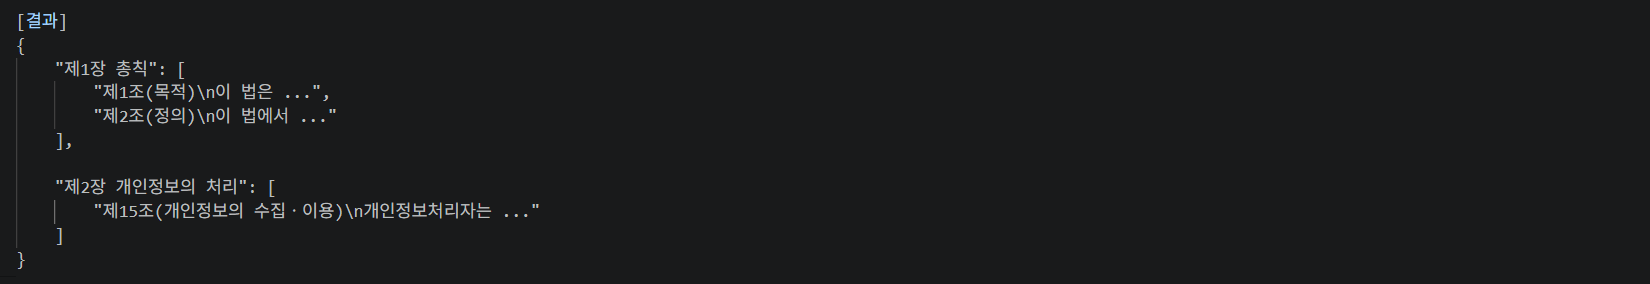

## 6. 조문 중심 법률 파싱 함수
- 처리 과정: 원본 law_text -> 법률명/시행정보 등 제거 -> 부칙 제거 -> 조항별 분리 -> List[str]

In [8]:
def parse_law_without_chapters(law_text: str) -> list[str]:
    """
    장(Chapter) 구조가 없는 법률 문서에서
    머리말과 부칙을 제거한 후 조(Article) 단위로 분리하여 반환
    """

    # 문서 처음부터 제1조 직전까지 제거
    preamble_pattern = r"^.*?(?=제1조)"

    # '부칙'부터 문서 끝까지 제거
    appendix_pattern = r"부칙.*$"

    # 조 제목 괄호의 존재 여부와 관계없이 조 단위로 분리
    article_pattern = (
        r"(제\d+조(?:의\d+)?.*?)"
        r"(?=제\d+조(?:의\d+)?|$)"
    )

    main_text = re.sub(
        preamble_pattern,
        "",
        law_text,
        flags=re.DOTALL,
    )

    main_text = re.sub(
        appendix_pattern,
        "",
        main_text,
        flags=re.DOTALL,
    )

    return [
        article.strip()
        for article in re.findall(
            article_pattern,
            main_text,
            flags=re.DOTALL,
        )
        if article.strip()
    ]


## 7. PDF 로딩과 헤더 정리


In [9]:
def load_pdf_text(pdf_path: Path, remove_header_pattern: str) -> str:
    """
    PDF 파일을 읽어 텍스트를 추출하고,
    반복되는 머리글을 제거한 후 전체 페이지를 하나의 문자열로 반환
    """

    if not pdf_path.exists():
        raise FileNotFoundError(f"PDF 파일이 존재하지 않습니다: {pdf_path}")

    pages = PyPDFLoader(str(pdf_path)).load()

    if not pages:
        raise ValueError(f"PDF에서 페이지를 읽지 못했습니다: {pdf_path}")

    cleaned_pages = [
        re.sub(
            remove_header_pattern,
            "",
            page.page_content,
        ).strip()
        for page in pages
    ]

    law_text = "\n".join(
        text for text in cleaned_pages if text
    ).strip()

    if not law_text:
        raise ValueError(
            f"PDF 텍스트가 비어 있습니다. PDF가 이미지 PDF인지 확인하세요: {pdf_path}"
        )

    return law_text


## 8. LangChain Document 생성
- LawSource 설정 하나를 받아서 해당 PDF를 찾고 → 텍스트를 읽고 → 장 구조 유무에 따라 파싱한 뒤 → LangChain의 Document 리스트로 변환하는 핵심 함수

In [10]:
def build_documents(source: LawSource) -> list[Document]:
    """
    LawSource 설정에 맞는 PDF를 찾아 파싱하고
    LangChain Document 리스트로 변환
    """

    pdf_path = find_pdf(source.filename_keyword)

    law_text = load_pdf_text(
        pdf_path,
        source.remove_header_pattern,
    )

    documents: list[Document] = []

    if source.has_chapters:
        parsed = parse_law_with_chapters(law_text)

        for chapter, articles in parsed.items():
            for article in articles:
                metadata = {
                    "source": str(pdf_path),
                    "chapter": chapter,
                    "name": source.name,
                }

                content = (
                    f"[법률정보]\n"
                    f"다음 조항은 {source.name} {chapter}에서 발췌한 내용입니다.\n\n"
                    f"[법률조항]\n{article}"
                )

                documents.append(
                    Document(
                        page_content=content,
                        metadata=metadata,
                    )
                )

    else:
        articles = parse_law_without_chapters(law_text)

        for article in articles:
            metadata = {
                "source": str(pdf_path),
                "name": source.name,
            }

            content = (
                f"[법률정보]\n"
                f"다음 조항은 {source.name}에서 발췌한 내용입니다.\n\n"
                f"[법률조항]\n{article}"
            )

            documents.append(
                Document(
                    page_content=content,
                    metadata=metadata,
                )
            )

    if not documents:
        raise ValueError(
            f"{source.name} 문서 파싱 결과가 비어 있습니다. "
            f"PDF 형식 또는 정규식을 확인하세요.\n"
            f"PDF: {pdf_path}\n"
            f"텍스트 길이: {len(law_text)}"
        )

    return documents


## 9. Chroma Collection 생성
- 매개변수
    - documents	: Chroma에 저장할 문서들
    - collection_name : Chroma Collection 이름
    - embedding_model_name : Ollama 임베딩 모델
    -  None : 별도의 값을 반환하지 않음


In [11]:
def create_collection(
    documents: Iterable[Document],
    collection_name: str,
    embedding_model_name: str,
) -> None:
    """
    Document 목록을 임베딩한 후
    Chroma Vector DB의 지정된 Collection에 저장
    """

    docs = list(documents)

    # 빈 리스트가 Chroma에 전달되면
    # "Expected Embeddings to be non-empty..." 오류가 발생할 수 있으므로 사전 검사
    if not docs:
        raise ValueError(
            f"{collection_name}: 저장할 Document가 없습니다."
        )

    embeddings = OllamaEmbeddings(
        model=embedding_model_name
    )

    Chroma.from_documents(
        documents=docs,
        embedding=embeddings,
        collection_name=collection_name,
        persist_directory=str(CHROMA_DIR),
    )


## 10. 전체 DB 생성 실행 함수

In [12]:
def main( reset: bool = False, embedding_model: str = "bge-m3") -> None:
    """
    Jupyter Notebook용 DB 생성 실행 함수

    reset=True
        기존 chroma_db 폴더를 삭제하고 새로 생성

    embedding_model
        Ollama Embedding 모델 이름
    """

    # 필요한 폴더가 없으면 생성
    DATA_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    # reset=True인 경우 기존 DB 전체 삭제
    if reset and CHROMA_DIR.exists():
        print(f"기존 Chroma DB 삭제: {CHROMA_DIR}")
        shutil.rmtree(CHROMA_DIR)

    CHROMA_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    print(f"Embedding model: {embedding_model}")

    # 등록된 법률을 하나씩 처리
    for index, source in enumerate(
        LAW_SOURCES,
        start=1,
    ):
        print(
            f"\n[{index}/{len(LAW_SOURCES)}] "
            f"{source.name}"
        )

        # PDF → Document
        docs = build_documents(source)

        print(
            f"  - PDF 파싱 완료: "
            f"{len(docs)}개 Document"
        )

        # Document → Embedding → Chroma
        create_collection(
            documents=docs,
            collection_name=source.collection_name,
            embedding_model_name=embedding_model,
        )

        print(
            f"  - Chroma 저장 완료: "
            f"{source.collection_name}"
        )

    print(f"\n전체 완료: {CHROMA_DIR}")


## 11. 실행
- pip install pypdf 설치 필요


In [16]:
# ============================================================
# DB 생성 실행
# ============================================================
#
# 처음부터 다시 생성하려면:
#   main(reset=True)
#
# 기존 chroma_db 폴더를 유지하려면:
#   main(reset=False)
#
# Ollama에서 bge-m3가 설치되어 있어야 합니다.
# 터미널:
#   ollama pull bge-m3
# ============================================================

main(
    reset=False,
    embedding_model="bge-m3",
)


Embedding model: bge-m3

[1/4] 개인정보 보호법
  - PDF 파싱 완료: 424개 Document


ResponseError: Post "http://127.0.0.1:9763/tokenize": dial tcp 127.0.0.1:9763: connectex: No connection could be made because the target machine actively refused it. (status code: 400)